미분
x가 조금 변할 때 y가 얼마나 변하는 지
변화량을 조회하는 방법

y가 어떻게 변하는지 궁금할 때, 필요없는 부분을 걸러서 "순수한 변화량"만 조회할 수 있게 해주는 도구

손실함수
모델은 정확성이 높아야 사용이 가능하다. 그 정확성을 올리기위해 사용되는 도구

모델이 틀린 정도를 숫자로 보여주는 계량기로,
모델이 완벽하면 손실 = 0
모델이 틀릴수록 손실 값이 커짐
최종적으로 손실값을 최소화(minimize), 0 에 가깝게 하는 게 목표이다.

손실함수의 종류 2가지
MSE (Mean Squared Error, 평균 제곱 오차)
Cross-Entropy (교차 엔트로피)

손실이 가장 작은 지점 찾기

#### 확률적 경사 하강법 SGD
> SGD는 그 산에서 가장 낮은 곳(가장 정확한 모델)을 찾아가는 과정
```
모델의 오차(비용)을 최소화하는 파라미터(가중치)를 찾기위한 최적화 방법
현재위치 : 모델의 현재 파라미터
산의 높이 : 모델의 오차
기울기 : 반대방향으로 가야 가장 빠르게 낮아진다
```

```
배치경사 하강법 : 산 전체의 지형을 모두 조사해서 가장 가파른 방향을 찾아 한걸음씩 내려가는 구조
(한번에 전체데이터를 사용한다.)
장점 : 기울기 계산이 매우 정확
단점 : 데이터가 많으면 매우 느리고 리소스를 많이 사용

확률 경사하강법 : 무작위로 한 지점을 지정하여 보고 그곳의 경사를 따라서 내려간다
SGD는 무작위로 샘플 한개의 오차를 계산하고 파라미터를 업데이트
이 과정을 모든 데이터에 대해서 빠르게 반복

무작위성의 장점 : 지역 최저점(local minimum)에 갇히지 않고 다 낮은 전역 최저점(global minimum)
-> 무작위로 여러번 반복하나?
    무작위로 하더라도 적은 횟수로 하면 지역 최저점에 갇힐 가능성이 있는것 같은데
```

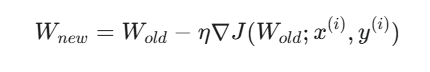

n(에타) : 학습률 learning late
SGD에서
학습률이 좋다 라는 건, 산을 내려갈때 보폭이 좁다는 것

보폭이 좁으면 산을 내려가는 데 시간이 오래가지만 정확하게 측정할 수 있다.
보폭이 넓으면 산을 내려가는 데 시간이 빠르지만 정학하게 측정하기 어렵다.

그래서 기울기가 급하면 보폭을 늘리다가
기울기가 완만해지면 보폭을 줄인다.
그렇게 해서 정교하고 빠르게 산의 골을 금방 찾을 수있다.

```
Wnew : 새로운 가중치
Wwold : 현재 가중치
n(에타) : 학습률 learning late 너무 크면 최적점을 지나고 너무 작으면 학습이 매우 느려진다
나블라 (역삼각형 기호) : 기울기 Gradient
J : 오차함수(비용함수) 현재 가중치 W_old에서 하나의 데이터 샘플에 대한 오차 ^

새로운 가중치 = 현재 가중치 오차를 키우는 기울기 방향과 반대로 학습률 만큼 이동한 값 ^
```

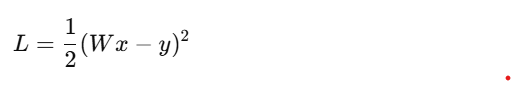

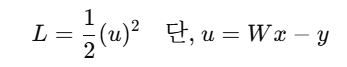

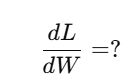

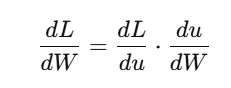

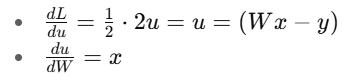

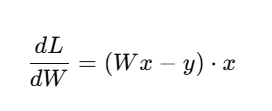

![SGD의 가중치 갱신 식.png](<attachment:SGD의 가중치 갱신 식.png>)
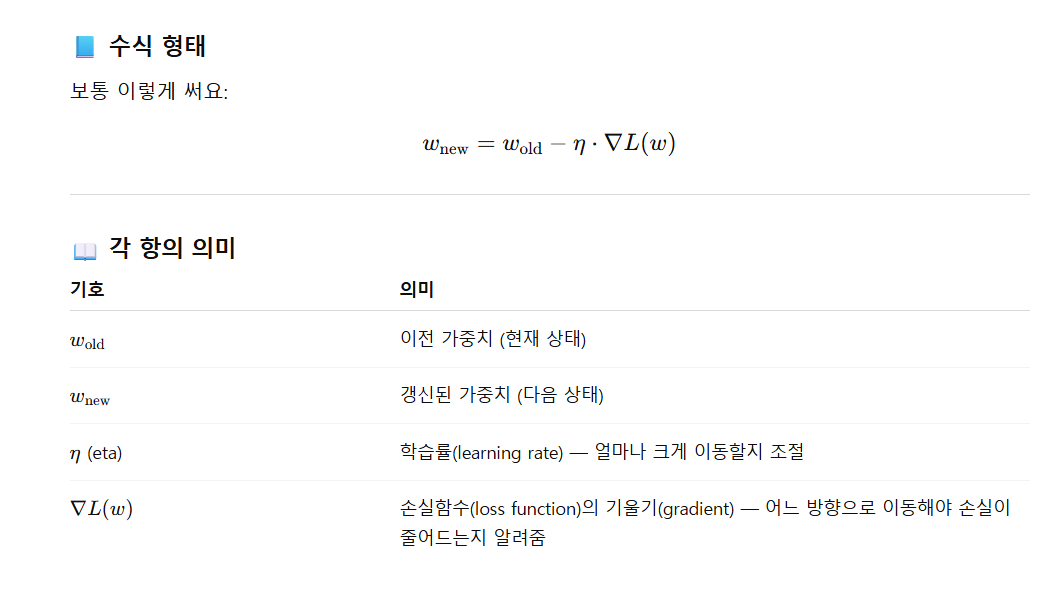

In [ ]:
# y= Wx
# 여기서 w는 그때 그때 구해서 구한다.
#  비용함수 오차 (Wx - y)**2/2 수식을 미분 (Wx - y)*x

# 예제 1)
#  x  y
# (3, 10)
# W_old = 2
# 학습률 (learning rate)
    # n = 0.1

# 기울기 J 구하기
# W_old^x -y)*x
(2*3-10)*3
# 기울기 -12

# W 업데이트 하기
# W_new = W_old - n ^ J
W_new = 2 - 0.1 * -12
W_new

3.2

확률경사 하강법 SGD의 로직을 수동으로 작성해보기

Malgun Gothic


<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Playdata2\AppData\Local\Temp\ipykernel_15136\3799880330.py:15: SyntaxWarning: invalid escape sequence '\p'
  font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part7\data\MALGUN.TTF"   # 폰트파일의 위치


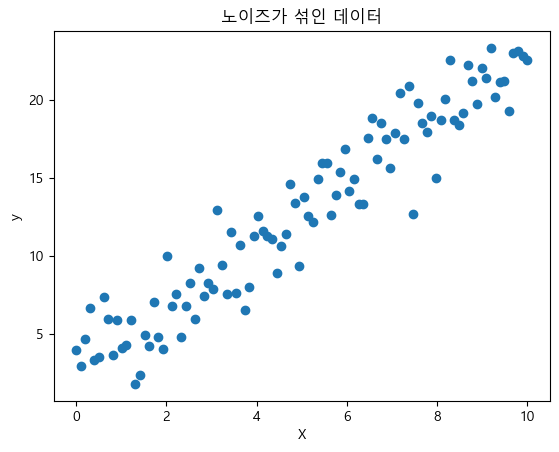

In [42]:
# 데이터 생성
import numpy as np
import matplotlib.pyplot as plt

# 랜덤 시드 고정
np.random.seed(42)

# 데이터 생성
X = np.linspace(0, 10, 100)  # 0~10까지 100개의 데이터
noise = np.random.randn(100) * 2  # 평균 0, 표준편차 2의 노이즈
y = 2 * X + 3 + noise  # 실제 값에 노이즈 추가

# matplotlib 한글 폰트 오류 문제 해결
from matplotlib import font_manager, rc
font_path = "C:\김지은\파이썬_src\pandas-data-analysis\part7\data\MALGUN.TTF"   # 폰트파일의 위치
                                  # Windows - Fonts
font_name = font_manager.FontProperties(fname=font_path).get_name()
print(font_name) # Malgun Gothic
rc('font', family=font_name)

# 데이터 시각화
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("노이즈가 섞인 데이터")
plt.show()


In [43]:
# 초기값
w = np.random.randn()
b = np.random.randn()
learning_rate = 0.01
epochs = 50

# 학습 기록 저장
history = []

# SGD 학습
for epoch in range(epochs):
    for i in range(len(X)):
        xi = X[i]
        yi = y[i]
        
        # 예측
        y_pred = w * xi + b
        
        # 오차 ^
        error = y_pred - yi
        
        # 경사 계산
        grad_w = error * xi
        grad_b = error
        
        # 파라미터 업데이트
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
    
    # 에포크마다 손실 기록
    y_preds = w * X + b
    loss = np.mean((y - y_preds)**2) / 2
    history.append(loss)
    print(f"Epoch {epoch+1:02d}: Loss={loss:.3f}, w={w:.3f}, b={b:.3f}")


Epoch 01: Loss=1.932, w=2.097, b=1.558
Epoch 02: Loss=1.854, w=2.078, b=1.750
Epoch 03: Loss=1.797, w=2.061, b=1.917
Epoch 04: Loss=1.756, w=2.046, b=2.061
Epoch 05: Loss=1.725, w=2.034, b=2.185
Epoch 06: Loss=1.703, w=2.023, b=2.293
Epoch 07: Loss=1.687, w=2.014, b=2.386
Epoch 08: Loss=1.676, w=2.006, b=2.466
Epoch 09: Loss=1.667, w=1.999, b=2.536
Epoch 10: Loss=1.662, w=1.993, b=2.596
Epoch 11: Loss=1.658, w=1.988, b=2.647
Epoch 12: Loss=1.655, w=1.983, b=2.692
Epoch 13: Loss=1.653, w=1.980, b=2.731
Epoch 14: Loss=1.652, w=1.976, b=2.764
Epoch 15: Loss=1.651, w=1.973, b=2.793
Epoch 16: Loss=1.651, w=1.971, b=2.818
Epoch 17: Loss=1.651, w=1.969, b=2.840
Epoch 18: Loss=1.651, w=1.967, b=2.859
Epoch 19: Loss=1.651, w=1.965, b=2.875
Epoch 20: Loss=1.651, w=1.964, b=2.889
Epoch 21: Loss=1.651, w=1.963, b=2.901
Epoch 22: Loss=1.651, w=1.961, b=2.911
Epoch 23: Loss=1.651, w=1.961, b=2.920
Epoch 24: Loss=1.651, w=1.960, b=2.928
Epoch 25: Loss=1.652, w=1.959, b=2.935
Epoch 26: Loss=1.652, w=1

In [ ]:
# 시각화 ^